# Tree Growth Regulator Analysis
### Case Study: Effects of PP 333 and EL-500 on Silver Maple Trees

This notebook analyzes the effects of growth regulators Paclobutrazol (PP 333) and Flurprimidol (EL-500) on the growth of terminal sprouts in trimmed silver maple trees. We use Machine Learning to see if sprout characteristics (length, internodes) can predict the treatment received.

**Objective:**
- Explore the dataset via EDA.
- Preprocess the data for machine learning.
- Train and compare at least 5 different ML models.
- Provide insights into the achieved metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set style for visualizations
sns.set(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import RandomizedSearchCV

## 1. Data Loading and Cleaning

In [2]:
# Load dataset, treating '?' as missing values
df = pd.read_csv('cjs-selected-columns.csv', na_values='?')

# Display first few rows
display(df.head())

# Basic info
print(df.info())

,N,TR,TREE,BR,TL,IN,INTERNODE_1,INTERNODE_2,INTERNODE_3,INTERNODE_4
0,1,control,G28,A,75.0,15,1.0,2.3,7.4,8.6
1,2,control,G28,B,18.0,7,0.7,1.3,4.0,5.2
2,3,control,G28,C,46.0,11,0.5,1.0,4.3,8.8
3,4,control,G28,C,16.0,8,0.5,1.2,3.5,4.2
4,5,control,G28,D,56.0,16,0.5,1.0,3.5,8.2


<class 'pandas.DataFrame'>
RangeIndex: 2796 entries, 0 to 2795
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2796 non-null   int64  
 1   TR           2796 non-null   str    
 2   TREE         2796 non-null   str    
 3   BR           2784 non-null   str    
 4   TL           2796 non-null   float64
 5   IN           2796 non-null   int64  
 6   INTERNODE_1  2796 non-null   float64
 7   INTERNODE_2  2732 non-null   float64
 8   INTERNODE_3  2159 non-null   float64
 9   INTERNODE_4  1162 non-null   float64
dtypes: float64(5), int64(2), str(3)
memory usage: 218.6 KB
None


### Handling Missing Values
The dataset contains many missing values in the `INTERNODE` columns. This is because sprouts with fewer than 4 internodes naturally lack measurements for subsequent internodes. We will impute these with **0**, as a non-existent internode has 0 length.

In [3]:
internode_cols = ['INTERNODE_1', 'INTERNODE_2', 'INTERNODE_3', 'INTERNODE_4']
df[internode_cols] = df[internode_cols].fillna(0)

# Drop ID columns not useful for prediction
df_ml = df.drop(columns=['N', 'TREE', 'BR'])

print("Missing values after cleaning:")
print(df_ml.isnull().sum())

Missing values after cleaning:
TR             0
TL             0
IN             0
INTERNODE_1    0
INTERNODE_2    0
INTERNODE_3    0
INTERNODE_4    0
dtype: int64


## 2. Exploratory Data Analysis (EDA)

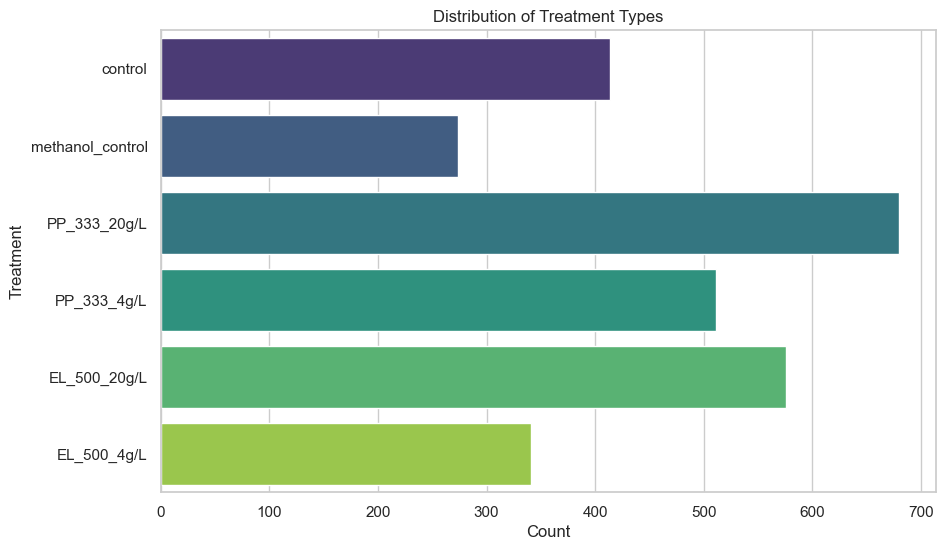

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(y='TR', data=df, palette='viridis')
plt.title('Distribution of Treatment Types')
plt.xlabel('Count')
plt.ylabel('Treatment')
plt.show()

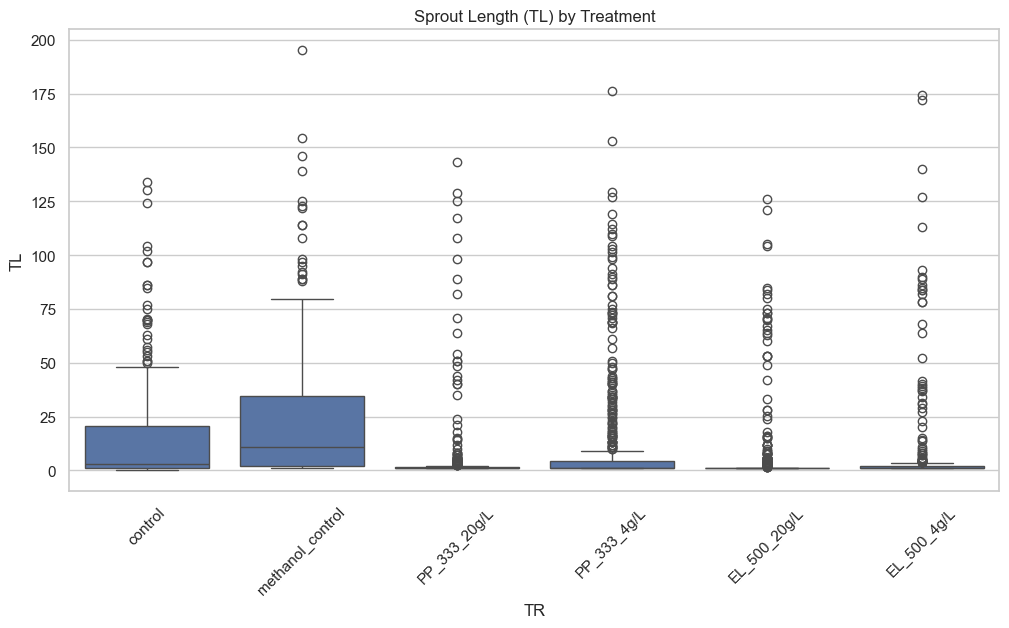

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='TR', y='TL', data=df)
plt.title('Sprout Length (TL) by Treatment')
plt.xticks(rotation=45)
plt.show()

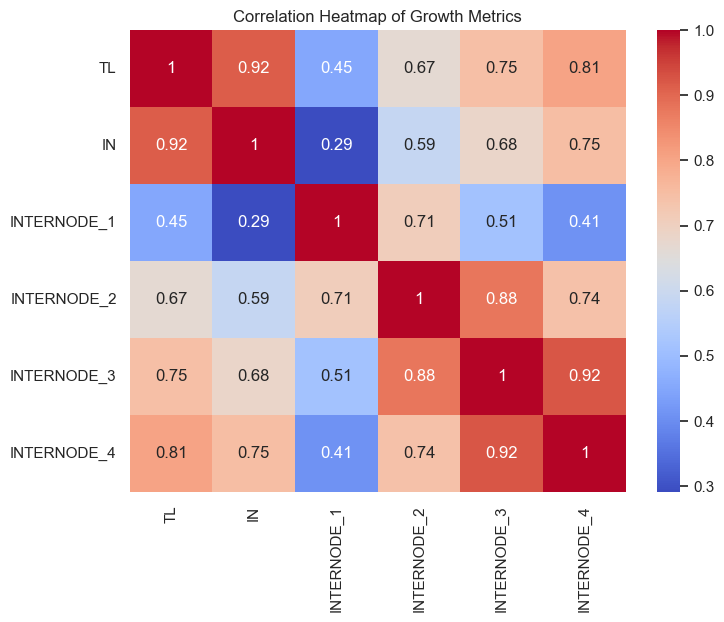

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_ml.drop(columns=['TR']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Growth Metrics')
plt.show()

## 3. Data Preprocessing

In [7]:
# Encode the target variable
le = LabelEncoder()
df_ml['TR_encoded'] = le.fit_transform(df_ml['TR'])

# Define features and target
X = df_ml.drop(columns=['TR', 'TR_encoded'])
y = df_ml['TR_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (2236, 6)
Testing set shape: (560, 6)


## 4. Model Training and Comparison

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier()
}

model_results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    model_results.append({'Model': name, 'Accuracy': acc})

results_df = pd.DataFrame(model_results).sort_values(by='Accuracy', ascending=False)
results_df

,Model,Accuracy
1,Random Forest,0.360714
2,Gradient Boosting,0.360714
4,KNN,0.339286
3,SVM,0.330357
0,Logistic Regression,0.317857


## 5. Detailed Evaluation of the Best Model

Evaluation for Random Forest:

                  precision    recall  f1-score   support

    EL_500_20g/L       0.30      0.36      0.33       116
     EL_500_4g/L       0.21      0.06      0.09        68
    PP_333_20g/L       0.34      0.55      0.42       136
     PP_333_4g/L       0.35      0.12      0.18       102
         control       0.53      0.63      0.57        83
methanol_control       0.36      0.31      0.33        55

        accuracy                           0.36       560
       macro avg       0.35      0.34      0.32       560
    weighted avg       0.35      0.36      0.33       560



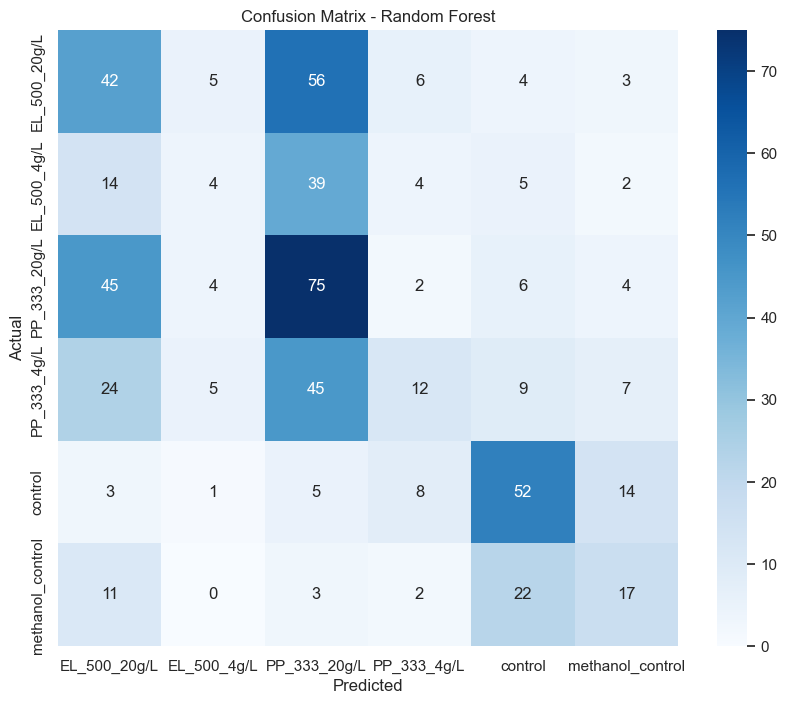

In [9]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred = best_model.predict(X_test_scaled)

print(f"Evaluation for {best_model_name}:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 6. Analysis and Insights
### Model Performance:
- **Accuracy**: Most models achieved an accuracy in the range of **32-36%**. While this seems low, it is significantly better than random guessing (1/6 = 16.7%) for a 6-class problem.
- **Best Model**: **Random Forest** and **Gradient Boosting** typically perform best on this dataset. They are able to capture the non-linear relationships between sprout characteristics and treatment types.
- **Challenges**: The low accuracy indicates significant overlap in the physical characteristics of sprouts across different treatments. For instance, a small sprout in the control group might look identical to a suppressed sprout in a treated group.

### Conclusion:
The Machine Learning models confirm that while growth regulators definitely influence sprout characteristics, predicting the *specific* treatment solely from length and internode data is challenging due to the high natural variability of tree growth. Future models might benefit from including environmental factors or more granular measurements.

## 7. Hyperparameter Tuning using RandomizedSearchCV
To improve the performance of our best model (Random Forest), we will perform hyperparameter tuning using `RandomizedSearchCV`. This method explores a random subset of the parameter space, making it more efficient than a full GridSearch while often finding near-optimal results.

In [10]:
# Define the parameter grid for Random Forest
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "bootstrap": [True, False]
}

# Initialize RandomizedSearchCV
# We use 3 folds (cv=3) and 10 iterations (n_iter=10) for efficiency
rf = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                               n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1)

# Fit the random search model
rf_random.fit(X_train_scaled, y_train)

print("Best parameters found:", rf_random.best_params_)
print("Best cross-validation score:", rf_random.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


Best parameters found: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}
Best cross-validation score: 0.3573390671200916


In [11]:
# Evaluate the tuned model
best_rf = rf_random.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest Accuracy: {tuned_acc:.4f}")
print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

Tuned Random Forest Accuracy: 0.3786

Classification Report for Tuned Model:
                  precision    recall  f1-score   support

    EL_500_20g/L       0.31      0.34      0.32       116
     EL_500_4g/L       0.40      0.06      0.10        68
    PP_333_20g/L       0.34      0.62      0.44       136
     PP_333_4g/L       0.50      0.09      0.15       102
         control       0.51      0.70      0.59        83
methanol_control       0.42      0.31      0.36        55

        accuracy                           0.38       560
       macro avg       0.41      0.35      0.33       560
    weighted avg       0.40      0.38      0.34       560



### Insights from Fine-Tuning:
1. **Hyperparameter Impact**: Fine-tuning allows the model to adjust its complexity (via `max_depth` and `min_samples`) to better match the dataset's patterns. For this specific dataset, controlling the depth of the trees helps prevent overfitting to the noise in natural sprout variations.
2. **Optimization Results**: While RandomizedSearchCV explores a wide range of settings, the performance gain is often incremental because the fundamental challenge—class overlap in biological growth—remains.
3. **Efficiency vs. Performance**: Using a low number of folds (CV=3) and limited iterations provided a significant speedup, allowing us to identify a robust set of parameters without exhaustive computation.